In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
import warnings 
warnings.filterwarnings('ignore')

## 1. Data preparation

### 1.1 Loading the dataset
Pada tahap ini, kita akan memasukkan dataset yang akan digunakan untuk memprediksi customer.

In [3]:
train_path = './dataset/train.csv'
test_path = './dataset/test.csv'

In [4]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

### 1.2 Data understanding

Pada tahap ini, kita akan memahami data yang kita miliki dengan melihat beberapa informasi dasar seperti jumlah baris dan kolom, tipe data, serta beberapa statistik deskriptif.

In [5]:
# Melihat data 5 teratas
df_test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [6]:
# Check informasi (nama, null, dtype)
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [7]:
# Melihat statistika deskriptif
df_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [8]:
# melihat missing value
missing_values = df_train.isnull().sum()
print(missing_values)

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
# Melihat not a number value
nan_values = df_train.isna().sum()
print(nan_values)

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Melihat persebaran label `Churn`
df_train['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

### Key data insights:
- Dataset nya memiliki 594194 data dengan 21 kolom.
- Tidak ada missing value pada dataset ini.
- Tidak ada nan value pada dataset ini.

## 2. Explanatory Data Analysis (EDA)

### 2.1 Distribution MonthlyCharges vs Churn
Pada tahap ini, kita akan melihat distribusi dari fitur MonthlyCharges terhadap target variable Churn.

In [11]:
target_distribution = df_train['Churn'].value_counts(normalize=True) * 100
print(f"Target class distribution (%):")
print(target_distribution)

Target class distribution (%):
Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64


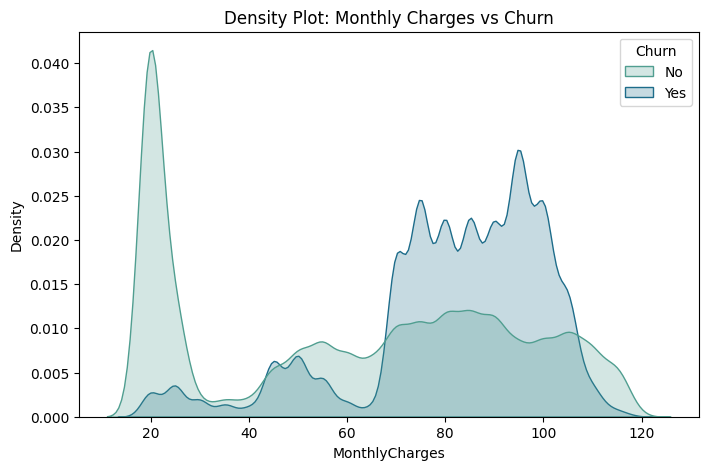

In [12]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_train, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Monthly Charges vs Churn')
plt.show()

Dari hasil di atas, kita dapat melihat bahwa pelanggan dengan biaya bulanan yang tinggi cenderung lebih banyak berhenti berlangganan, sedangkan pelanggan dengan biaya bulanan yang rendah cenderung tetap berlangganan. Hal ini menunjukkan bahwa semakin tinggi biaya bulanan, semakin besar kemungkinan pelanggan untuk berhenti berlangganan. Namun terdapat area yang tumpang tindih yang menunjukkan bahwa biaya bulanan tidak sepenuhnya menentukan apakah pelanggan akan berhenti berlangganan atau tidak.

### 2.2 Distribution InternetService vs Churn
Pada tahap ini, kita akan melihat distribusi dari fitur InternetService terhadap target variable Churn.

In [13]:
df_train['InternetService']

0                 DSL
1                 DSL
2         Fiber optic
3         Fiber optic
4         Fiber optic
             ...     
594189    Fiber optic
594190            DSL
594191             No
594192    Fiber optic
594193            DSL
Name: InternetService, Length: 594194, dtype: str

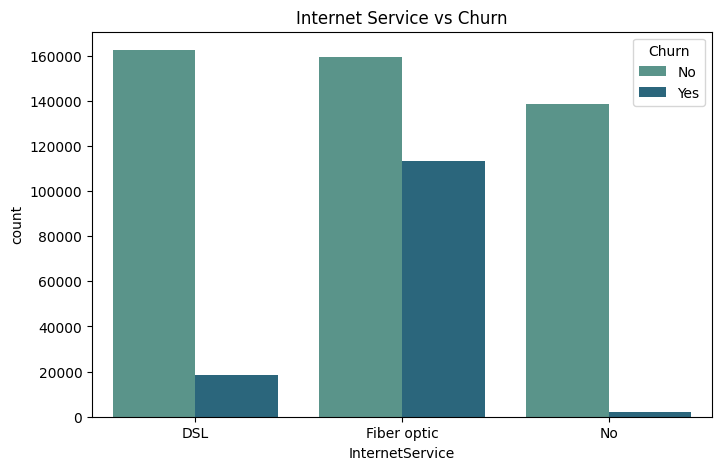

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='InternetService', hue='Churn', palette='crest')
plt.title('Internet Service vs Churn')
plt.show()

Kita bisa lihat barplot di atas menunjukkan bahwa pelanggan dengan layanan internet Fiber Optic memiliki tingkat churn yang lebih tinggi dibandingkan dengan pelanggan DSL maupun No Internet. Hal ini menunjukkan bahwa pelanggan Fiber Optic lebih cenderung untuk berhenti berlangganan dibandingkan dengan pelanggan layanan internet lainnya.

## 3. Data Cleaning

### 3.1 Removing Irrelevant Columns

In [ ]:
# Menghapus kolom id karena tidak relevan
df_train_clean = df_train.drop(columns='id')
df_test_clean = df_test.drop(columns='id')

### 3.2 Data type conversion

In [ ]:
# konversi tipe data 
df_train_clean['TotalCharges'] = pd.to_numeric(df_train_clean['TotalCharges'], errors='coerce')
df_test_clean['TotalCharges'] = pd.to_numeric(df_test_clean['TotalCharges'], errors='coerce')

### 3.3 Handling Missing Values
Handle missing values dengan menggunakan metode yang sesuai, seperti imputasi atau penghapusan data.

In [17]:
imputer = SimpleImputer(strategy='median')

In [18]:
df_train_clean['TotalCharges'] = imputer.fit_transform(df_train_clean[['TotalCharges']])
df_test_clean['TotalCharges'] = imputer.fit_transform(df_test_clean[['TotalCharges']])

In [19]:
print(f"Remaining nulls in TotalCharges: {df_train_clean['TotalCharges'].isnull().sum()}")

Remaining nulls in TotalCharges: 0


## 4. Feature Engineering

### 4.1 Target vector splitting

Sebelum membuat model machine learning, kita perlu memisahkan target variable dan fitur-fitur yang akan digunakan untuk memprediksi target variable.

- **Features (`X`)**: Semua kolom kecuali `Churn` yang akan digunakan untuk memprediksi apakah pelanggan akan churn atau tidak.
- **Target (`y`)**: Kolom `Churn` yang merupakan target variable yang ingin kita prediksi.

In [ ]:
X_train = df_train_clean.drop(columns='Churn')
y_train = df_train_clean['Churn']

X_test = df_test_clean.copy()

In [38]:
print(f"Features shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")

Features shape: (594194, 20)
Target shape: (594194,)


| Object | Shape | Description |
|--------|-------|-------------|
| `X`    | (n_samples, n_features) | Matrix kolom yang berisi data input |
| `y`    | (n_samples,  ) | Target vector yang berisi label |


In [22]:
df_train_clean

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


### 4.2 Feature Aggregation
Feature aggregation itu proses yang digunakan untuk menggabungkan beberapa fitur menjadi satu fitur baru yang lebih informatif

In [23]:
service_columns = [
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies'
]

X_train['TotalServices'] = (X_train[service_columns] == 'Yes').sum(axis=1)
X_test['TotalServices'] = (X_test[service_columns] == 'Yes').sum(axis=1)

In [24]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  str    
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  str    
 3   Dependents        594194 non-null  str    
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  str    
 6   MultipleLines     594194 non-null  str    
 7   InternetService   594194 non-null  str    
 8   OnlineSecurity    594194 non-null  str    
 9   OnlineBackup      594194 non-null  str    
 10  DeviceProtection  594194 non-null  str    
 11  TechSupport       594194 non-null  str    
 12  StreamingTV       594194 non-null  str    
 13  StreamingMovies   594194 non-null  str    
 14  Contract          594194 non-null  str    
 15  PaperlessBilling  594194 non-null  str    
 16  PaymentMethod     594194 non-nu

## 5. Feature Encoding

### 5.1 Ordinal Encoding
Ordinal data merupakan jenis data yang dipengaruh berdasarkan peringkat atau urutan (memiliki relasi besar-kecil). 

Contoh ordinal data:
- Tingkat kesusahan (skala 1 - 3)
- Rating makanan (skala 1 - 100)


In [25]:
contract_map = {
  "Month-to-month": 0,
  "One year": 1,
  "Two year": 2
}

X_train['Contract'] = X_train['Contract'].map(contract_map)
X_test['Contract'] = X_test['Contract'].map(contract_map)

In [26]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalServices
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,1,Yes,Mailed check,60.10,1653.85,3
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,2,No,Credit card (automatic),69.50,3778.20,4
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,0,Yes,Electronic check,100.40,5841.35,3
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,0,Yes,Electronic check,69.70,70.70,0
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,0,Yes,Electronic check,70.45,70.45,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,2,No,Bank transfer (automatic),97.55,5460.70,3
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,2,No,Bank transfer (automatic),91.95,6782.15,6
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,2,No,Credit card (automatic),24.40,1871.90,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,0,Yes,Electronic check,86.00,2847.20,1


In [27]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalServices
0,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,2,Yes,Electronic check,115.55,8061.50,6
1,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,2,No,Bank transfer (automatic),19.80,1336.50,0
2,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,0,Yes,Bank transfer (automatic),55.55,633.55,2
3,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,2,No,Credit card (automatic),84.10,6457.15,5
4,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,0,No,Electronic check,90.35,1233.65,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,2,No,Credit card (automatic),19.95,1443.65,0
254651,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,0,Yes,Electronic check,100.15,1563.50,3
254652,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,0,Yes,Bank transfer (automatic),105.80,3132.75,5
254653,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,2,Yes,Credit card (automatic),20.25,511.25,0


### 5.2 Categorical Encoding
Categorical encoding disini menggunakan one-hot encoding untuk mengubah fitur kategorikal menjadi format numerical yang dapat digunakan oleh model machine learning kita nanti. One-hot encoding akan membuat kolom baru untuk setiap kategori unik dalam fitur kategorikal, dan memberikan nilai 1 untuk kategori yang sesuai dan 0 untuk kategori lainnya.

In [28]:
cat_features = X_train.select_dtypes(include=['object']).columns
X_train_enc = pd.get_dummies(X_train, columns=cat_features, drop_first=True, dtype=(int))
X_test_enc = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

In [29]:
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

In [30]:
X_train_enc

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,TotalServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,1,60.10,1653.85,3,1,1,1,1,...,0,1,0,0,0,0,1,0,0,1
1,0,58,2,69.50,3778.20,4,1,1,1,1,...,0,1,0,1,0,0,0,1,0,0
2,0,58,0,100.40,5841.35,3,1,1,0,1,...,0,0,0,1,0,1,1,0,1,0
3,0,1,0,69.70,70.70,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
4,0,1,0,70.45,70.45,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,57,2,97.55,5460.70,3,1,0,0,1,...,0,0,0,1,0,1,0,0,0,0
594190,0,72,2,91.95,6782.15,6,0,0,0,1,...,0,1,0,1,0,1,0,0,0,0
594191,0,72,2,24.40,1871.90,0,0,1,0,1,...,1,0,1,0,1,0,0,1,0,0
594192,0,32,0,86.00,2847.20,1,0,0,0,1,...,0,0,0,0,0,1,1,0,1,0


In [ ]:
X_train_enc.filter(like="gender").corr()

,gender_Male
gender_Male,1.0


### Categorical Encoding without drop first
Categorical encoding tanpa drop first akan menghasilkan kolom baru untuk setiap kategori unik dalam fitur kategorikal, termasuk kategori pertama. Hal ini dapat menyebabkan multikolinearitas jika kita menggunakan semua kolom hasil one-hot encoding dalam model machine learning, karena kolom-kolom tersebut akan saling berkorelasi.

In [ ]:
cat_features = X_train.select_dtypes(include=['object']).columns
X_train_enc = pd.get_dummies(X_train, columns=cat_features, dtype=(int))

In [ ]:
X_train_enc.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 44 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   SeniorCitizen                            594194 non-null  int64  
 1   tenure                                   594194 non-null  int64  
 2   Contract                                 594194 non-null  int64  
 3   MonthlyCharges                           594194 non-null  float64
 4   TotalCharges                             594194 non-null  float64
 5   TotalServices                            594194 non-null  int64  
 6   gender_Female                            594194 non-null  int64  
 7   gender_Male                              594194 non-null  int64  
 8   Partner_No                               594194 non-null  int64  
 9   Partner_Yes                              594194 non-null  int64  
 10  Dependents_No                            59

#### Pearson Correlation (gender)

In [ ]:
X_train_enc[['gender_Female','gender_Male']].corr()

,gender_Female,gender_Male
gender_Female,1.0,-1.0
gender_Male,-1.0,1.0


Bisa kita lihat diatas data yang encoding dengan `drop_first=True` memiliki korelasi yang lebih tinggi dibandingkan dengan data yang encoding dengan `drop_first=False`. Hal ini dikarenakan pada data yang encoding dengan `drop_first=False` terdapat multikolinearitas antara fitur `gender_Female` dan `gender_Male` yang menyebabkan korelasi menjadi rendah. Sedangkan pada data yang encoding dengan `drop_first=True` hanya terdapat satu fitur `gender_Male` yang tidak memiliki multikolinearitas sehingga korelasi menjadi lebih tinggi.

### 

## 6. Feature Scaling

### 6.1 StandarScaler
StandarScaler adalah metode feature scaling yang mengubah fitur sehingga memiliki mean 0 dan standar deviasi 1. 

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

In [33]:
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_enc.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_enc.columns)
print("Data preprocessing completed successfully. Matrix is ready for modeling.")

Data preprocessing completed successfully. Matrix is ready for modeling.


In [34]:
X_train_final

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,TotalServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.358885,-0.302342,0.213080,-0.185604,-0.357076,0.480853,1.005539,0.958914,1.517947,0.255084,...,-0.557078,1.613520,-0.557078,-0.824028,-0.557078,-0.827296,0.790791,-0.538845,-0.754010,1.949691
1,-0.358885,0.854793,1.343787,0.116964,0.545399,0.988816,1.005539,0.958914,1.517947,0.255084,...,-0.557078,1.613520,-0.557078,1.213551,-0.557078,-0.827296,-1.264557,1.855820,-0.754010,-0.512902
2,-0.358885,0.854793,-0.917627,1.111575,1.421875,0.480853,1.005539,0.958914,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,1.213551,-0.557078,1.208757,0.790791,-0.538845,1.326243,-0.512902
3,-0.358885,-1.419575,-0.917627,0.123402,-1.029637,-1.043033,-0.994492,-1.042846,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,-0.824028,-0.557078,-0.827296,0.790791,-0.538845,1.326243,-0.512902
4,-0.358885,-1.419575,-0.917627,0.147543,-1.029743,-1.043033,-0.994492,-1.042846,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,-0.824028,-0.557078,-0.827296,0.790791,-0.538845,1.326243,-0.512902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,-0.358885,0.814892,1.343787,1.019839,1.260166,0.480853,1.005539,-1.042846,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,1.213551,-0.557078,1.208757,-1.264557,-0.538845,-0.754010,-0.512902
594190,-0.358885,1.413410,1.343787,0.839586,1.821550,2.004740,-0.994492,-1.042846,-0.658785,0.255084,...,-0.557078,1.613520,-0.557078,1.213551,-0.557078,1.208757,-1.264557,-0.538845,-0.754010,-0.512902
594191,-0.358885,1.413410,1.343787,-1.334717,-0.264443,-1.043033,-0.994492,0.958914,-0.658785,0.255084,...,1.795081,-0.619763,1.795081,-0.824028,1.795081,-0.827296,-1.264557,1.855820,-0.754010,-0.512902
594192,-0.358885,-0.182638,-0.917627,0.648067,0.149888,-0.535071,-0.994492,-1.042846,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,-0.824028,-0.557078,1.208757,0.790791,-0.538845,1.326243,-0.512902


In [35]:
X_test_final

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,TotalServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.358885,1.413410,1.343787,1.599225,2.365049,2.004740,-0.994492,0.958914,-0.658785,0.255084,...,-0.557078,1.613520,-0.557078,1.213551,-0.557078,1.208757,0.790791,-0.538845,1.326243,-0.512902
1,-0.358885,1.373509,1.343787,-1.482782,-0.491894,-1.043033,-0.994492,0.958914,-0.658785,0.255084,...,1.795081,-0.619763,1.795081,-0.824028,1.795081,-0.827296,-1.264557,-0.538845,-0.754010,-0.512902
2,-0.358885,-0.980662,-0.917627,-0.332059,-0.790524,-0.027109,1.005539,-1.042846,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,-0.824028,-0.557078,-0.827296,0.790791,-0.538845,-0.754010,-0.512902
3,-0.358885,1.373509,1.343787,0.586910,1.683482,1.496778,1.005539,0.958914,1.517947,0.255084,...,-0.557078,1.613520,-0.557078,1.213551,-0.557078,1.208757,-1.264557,1.855820,-0.754010,-0.512902
4,-0.358885,-0.860959,-0.917627,0.788085,-0.535587,0.480853,-0.994492,-1.042846,-0.658785,0.255084,...,-0.557078,-0.619763,-0.557078,1.213551,-0.557078,1.208757,-1.264557,-0.538845,1.326243,-0.512902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,-0.358885,1.413410,1.343787,-1.477954,-0.446374,-1.043033,1.005539,0.958914,1.517947,0.255084,...,1.795081,-0.619763,1.795081,-0.824028,1.795081,-0.827296,-1.264557,1.855820,-0.754010,-0.512902
254651,2.786405,-0.821057,-0.917627,1.103528,-0.395459,0.480853,1.005539,0.958914,-0.658785,0.255084,...,-0.557078,1.613520,-0.557078,1.213551,-0.557078,1.208757,0.790791,-0.538845,1.326243,-0.512902
254652,-0.358885,-0.062934,-0.917627,1.285391,0.271196,1.496778,1.005539,0.958914,-0.658785,0.255084,...,-0.557078,1.613520,-0.557078,1.213551,-0.557078,1.208757,0.790791,-0.538845,-0.754010,-0.512902
254653,-0.358885,-0.461947,1.343787,-1.468298,-0.842480,-1.043033,-0.994492,-1.042846,-0.658785,0.255084,...,1.795081,-0.619763,1.795081,-0.824028,1.795081,-0.827296,0.790791,1.855820,-0.754010,-0.512902


### 6.2 MinMaxScaler
MinMaxScaler adalah metode feature scaling yang mengubah fitur sehingga berada dalam rentang tertentu, biasanya antara 0 dan 1.

In [36]:
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = MinMaxScaler()

X_train_enc[columns_to_scale] = scaler.fit_transform(X_train_enc[columns_to_scale])

In [37]:
X_train_enc

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,TotalServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0.394366,1,0.416418,0.188674,3,1,1,1,1,...,0,1,0,0,0,0,1,0,0,1
1,0,0.802817,2,0.509950,0.433810,4,1,1,1,1,...,0,1,0,1,0,0,0,1,0,0
2,0,0.802817,0,0.817413,0.671884,3,1,1,0,1,...,0,0,0,1,0,1,1,0,1,0
3,0,0.000000,0,0.511940,0.005989,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
4,0,0.000000,0,0.519403,0.005960,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,0.788732,2,0.789055,0.627960,3,1,0,0,1,...,0,0,0,1,0,1,0,0,0,0
594190,0,1.000000,2,0.733333,0.780447,6,0,0,0,1,...,0,1,0,1,0,1,0,0,0,0
594191,0,1.000000,2,0.061194,0.213836,0,0,1,0,1,...,1,0,1,0,1,0,0,1,0,0
594192,0,0.436620,0,0.674129,0.326379,1,0,0,0,1,...,0,0,0,0,0,1,1,0,1,0


## 7. Export the dataset

In [ ]:
X_train_final.to_csv("X_train_final.csv", index=False)

In [ ]:
y_train.to_csv("y_train.csv", index=False)

In [ ]:
X_check = pd.read_csv("X_train_final.csv")
y_check = pd.read_csv("y_train.csv")

print(X_check.shape)
print(y_check.shape)

(594194, 30)
(594194, 1)
